# 情绪因子测试 (同样作为时序因子示例)

因子定义：`情绪因子 = ts_rank(涨停家数 - 跌停家数, 252) + ts_rank(昨日涨停今日溢价, 252)`

- 涨跌停家数差：每日全市场涨停家数 - 跌停家数
- 昨日涨停今日溢价：昨日涨停股票今日的收盘收益率（等权平均）
- ts_rank：过去252天的百分位排名（0-1）

In [70]:
# 获取数据
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append(r"C:\Users\20561\Desktop\策略")
from my_utils.fun import *
from my_utils.mapping import *
from my_utils.stock_api import stock_api
import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

start_date = dt.date(2023, 1, 1)
end_date = dt.date(2026, 1, 1)
print(f"测试时间范围: {start_date} ~ {end_date}")

测试时间范围: 2023-01-01 ~ 2026-01-01


In [71]:
# 读取日线数据
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open', 'close', 'pre_close', 'limit_up', 'limit_down'])
print(f"数据加载完成: {stock_data.shape}")
print(f"股票数量: {stock_data['code'].n_unique()}")
print(f"交易日数量: {stock_data['trading_date'].n_unique()}")

数据加载完成: (3691313, 33)
股票数量: 5309
交易日数量: 727


In [72]:
# 标记涨停状态
stock_data = mark_limit_status(stock_data)
print("涨停状态标记完成")
stock_data.select(['code', 'trading_date', 'close', 'limit_status', 'is_limit_up']).head(10)

涨停状态标记完成


code,trading_date,close,limit_status,is_limit_up
str,date,f64,str,bool
"""SHSE.600000""",2023-01-03,7.23,"""未涨停""",false
"""SHSE.600000""",2023-01-04,7.31,"""未涨停""",false
"""SHSE.600000""",2023-01-05,7.35,"""未涨停""",false
"""SHSE.600000""",2023-01-06,7.34,"""未涨停""",false
"""SHSE.600000""",2023-01-09,7.34,"""未涨停""",false
"""SHSE.600000""",2023-01-10,7.28,"""未涨停""",false
"""SHSE.600000""",2023-01-11,7.3,"""未涨停""",false
"""SHSE.600000""",2023-01-12,7.27,"""未涨停""",false
"""SHSE.600000""",2023-01-13,7.34,"""未涨停""",false


## 步骤1：计算每日市场情绪指标，包括:涨跌停家数差和昨日涨停今日溢价

```python

In [73]:
# 计算每日涨跌停家数
daily_stats = stock_data.group_by('trading_date').agg([
    pl.col('is_limit_up').sum().cast(pl.Int64).alias('limit_up_count'),
    ((pl.col('close') <= pl.col('limit_down') * 1.001)).sum().cast(pl.Int64).alias('limit_down_count')
]).sort('trading_date')

daily_stats = daily_stats.with_columns([
    (pl.col('limit_up_count') - pl.col('limit_down_count')).alias('limit_spread')
])

print("每日涨跌停统计:")
daily_stats.head(10)

每日涨跌停统计:


trading_date,limit_up_count,limit_down_count,limit_spread
date,i64,i64,i64
2023-01-03,116,3,113
2023-01-04,63,11,52
2023-01-05,52,12,40
2023-01-06,37,14,23
2023-01-09,46,8,38
2023-01-10,39,7,32
2023-01-11,31,13,18
2023-01-12,40,11,29
2023-01-13,38,10,28


In [74]:
# 计算昨日涨停股票今日的溢价
# 先标记每只股票每天是否是"昨日涨停"
stock_data = stock_data.sort(['code', 'trading_date'])
stock_data = stock_data.with_columns([
    pl.col('is_limit_up').shift(1).over('code').alias('yesterday_limit_up')
])

# 计算昨日涨停股票今日的收益率
stock_data = stock_data.with_columns([
    ((pl.col('close') - pl.col('pre_close')) / pl.col('pre_close') * 100).alias('today_return')
])

# 筛选出昨日涨停的股票，计算每日平均溢价
yesterday_limit_stocks = stock_data.filter(pl.col('yesterday_limit_up') == True)

daily_premium = yesterday_limit_stocks.group_by('trading_date').agg([
    pl.col('today_return').mean().alias('limit_up_premium'),
    pl.col('code').count().alias('pre_limit_up_stock_count')
]).sort('trading_date')

print("昨日涨停今日溢价统计:")
daily_premium.head(10)

昨日涨停今日溢价统计:


trading_date,limit_up_premium,pre_limit_up_stock_count
date,f64,u32
2023-01-04,2.035406,116
2023-01-05,0.449833,63
2023-01-06,0.256991,52
2023-01-09,1.456631,37
2023-01-10,1.593072,46
2023-01-11,1.674724,39
2023-01-12,0.959144,31
2023-01-13,1.299877,40
2023-01-16,2.568172,38


In [75]:
# 合并两个指标
market_sentiment = daily_stats.join(daily_premium, on='trading_date', how='left').sort('trading_date')
# 填充缺失的溢价（某些天可能没有昨日涨停股票）
market_sentiment = market_sentiment.with_columns([
    pl.col('limit_up_premium').fill_null(0)
])
print(f"市场情绪数据 shape: {market_sentiment.shape}")
market_sentiment.head(10)

市场情绪数据 shape: (727, 6)


trading_date,limit_up_count,limit_down_count,limit_spread,limit_up_premium,pre_limit_up_stock_count
date,i64,i64,i64,f64,u32
2023-01-03,116,3,113,0.0,null
2023-01-04,63,11,52,2.035406,116
2023-01-05,52,12,40,0.449833,63
2023-01-06,37,14,23,0.256991,52
2023-01-09,46,8,38,1.456631,37
2023-01-10,39,7,32,1.593072,46
2023-01-11,31,13,18,1.674724,39
2023-01-12,40,11,29,0.959144,31
2023-01-13,38,10,28,1.299877,40


## 步骤2：计算252日滚动百分位排名（ts_rank）

In [76]:
def rolling_percent_rank(series, window=252):
    """计算滚动百分位排名（0-1）"""
    ranks = []
    for i in range(len(series)):
        if i < window - 1:
            ranks.append(np.nan)
        else:
            window_data = series.iloc[i-window+1:i+1]
            current_value = series.iloc[i]
            # 计算当前值在窗口中的百分位
            rank = (window_data <= current_value).sum() / len(window_data)
            ranks.append(rank)
    return pd.Series(ranks, index=series.index)

# 转换为pandas进行计算
market_sentiment_pd = market_sentiment.to_pandas().set_index('trading_date')

# 计算涨跌停家数差的252日百分位排名
market_sentiment_pd['limit_spread_rank'] = rolling_percent_rank(market_sentiment_pd['limit_spread'], 252)

# 计算昨日涨停溢价的252日百分位排名
market_sentiment_pd['limit_up_premium_rank'] = rolling_percent_rank(market_sentiment_pd['limit_up_premium'], 252)

# 计算最终情绪因子
market_sentiment_pd['sentiment_factor'] = (
    market_sentiment_pd['limit_spread_rank'] + 
    market_sentiment_pd['limit_up_premium_rank']
)

print("情绪因子计算完成:")
market_sentiment_pd.tail(10)

情绪因子计算完成:


,limit_up_count,limit_down_count,limit_spread,limit_up_premium,pre_limit_up_stock_count,limit_spread_rank,limit_up_premium_rank,sentiment_factor
trading_date,,,,,,,,
2025-12-18,71,8,63,3.10302634,58.0,0.53968254,0.78571429,1.32539683
2025-12-19,84,7,77,3.21338033,71.0,0.73015873,0.81349206,1.54365079
2025-12-22,108,9,99,2.24808905,84.0,0.91269841,0.57539683,1.48809524
2025-12-23,68,16,52,1.20678515,108.0,0.37698413,0.30555556,0.68253968
2025-12-24,86,7,79,2.50086517,68.0,0.75396825,0.63888889,1.39285714
2025-12-25,95,2,93,3.40248128,86.0,0.89285714,0.86507937,1.75793651
2025-12-26,91,3,88,2.42599496,95.0,0.84920635,0.61507937,1.46428571
2025-12-29,90,25,65,0.53198260,91.0,0.56746032,0.18253968,0.75000000
2025-12-30,67,19,48,0.91154315,90.0,0.34523810,0.24603175,0.59126984


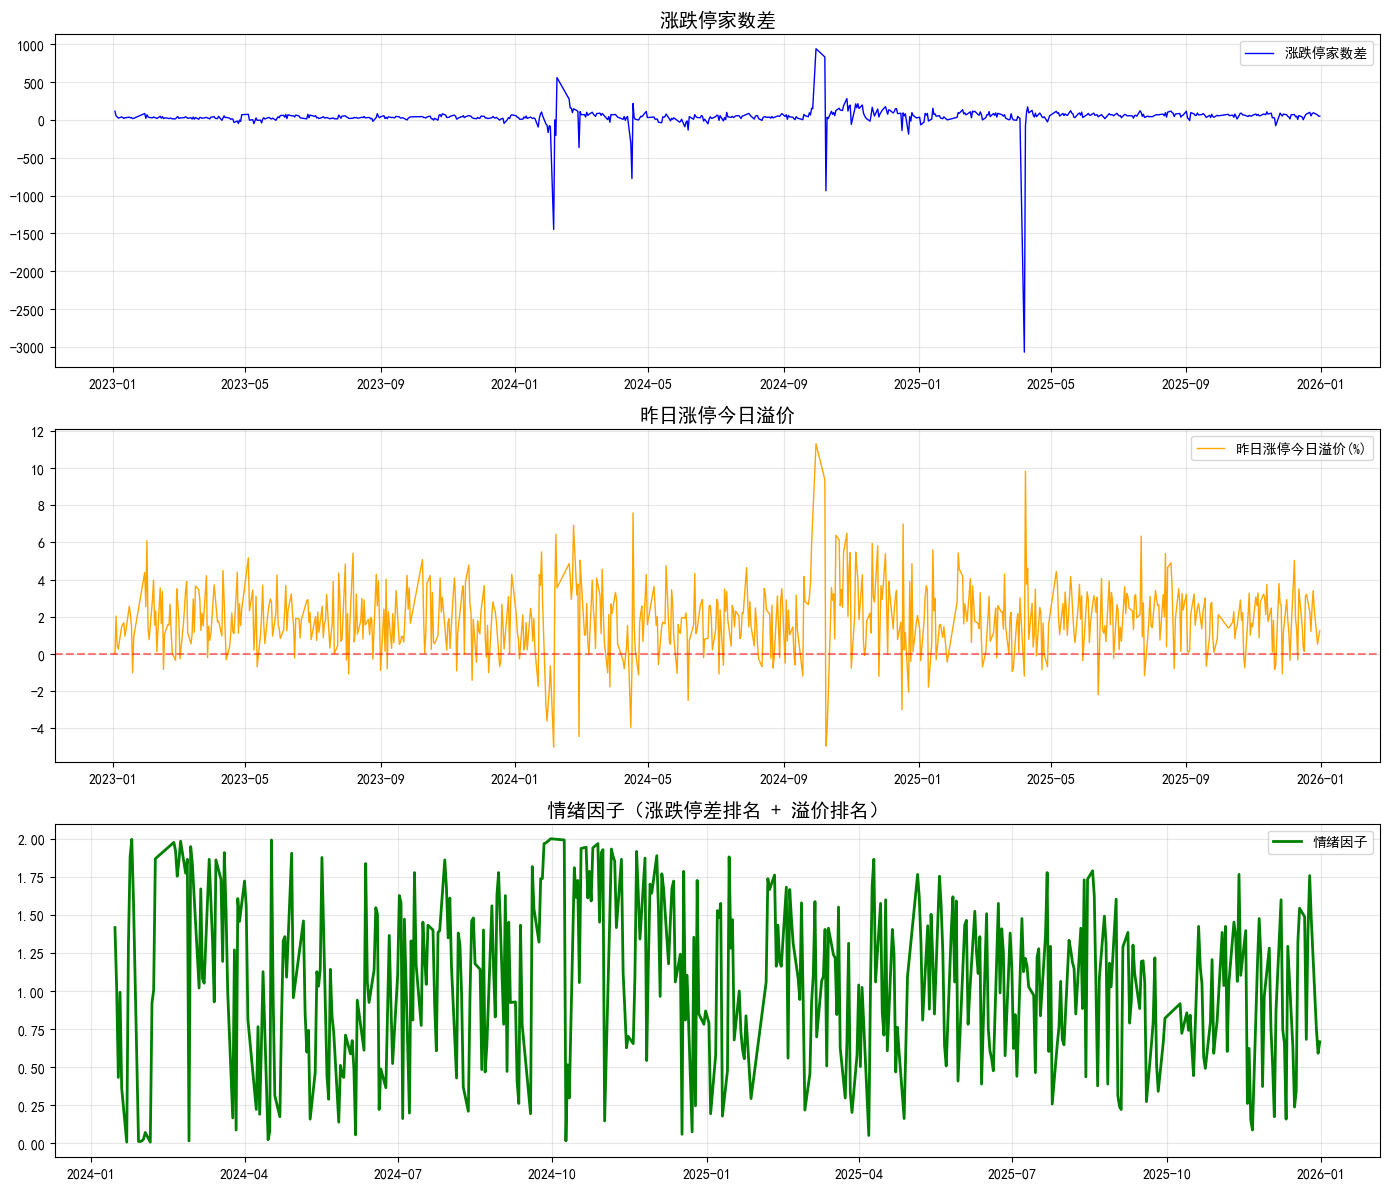

In [77]:
# 画出情绪因子时序图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 涨跌停家数差
axes[0].plot(market_sentiment_pd.index, market_sentiment_pd['limit_spread'], label='涨跌停家数差', color='blue', linewidth=1)
axes[0].set_title('涨跌停家数差', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 昨日涨停溢价
axes[1].plot(market_sentiment_pd.index, market_sentiment_pd['limit_up_premium'], label='昨日涨停今日溢价(%)', color='orange', linewidth=1)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('昨日涨停今日溢价', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

# 情绪因子
axes[2].plot(market_sentiment_pd.index, market_sentiment_pd['sentiment_factor'], label='情绪因子', color='green', linewidth=2)
axes[2].set_title('情绪因子（涨跌停差排名 + 溢价排名）', fontsize=14)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 步骤3：获取中证1000指数数据

In [78]:
# 使用gm_get_index_day_data获取中证1000指数
from my_utils.stock_api import stock_api
api = stock_api()

# 获取中证1000指数 (SHSE.000852)
print("正在获取中证1000指数数据...")
index_data = api.gm_get_index_day_data(
    index_code='SHSE.000852',
    start_date=start_date.strftime('%Y-%m-%d'),
    end_date=end_date.strftime('%Y-%m-%d')
)

print(f"中证1000指数数据获取完成: {index_data.shape}")
index_data.head(10)

正在获取中证1000指数数据...
中证1000指数数据获取完成: (727, 13)


,code,frequency,open,high,low,close,volume,amount,pre_close,position,bob,eob,trading_date
0,SHSE.000852,1d,6286.814,6433.786,6275.688,6423.701,13318168000,1.60707713e+11,6281.621,0,2023-01-03 00:00:00+08:00,2023-01-03 00:00:00+08:00,2023-01-03
1,SHSE.000852,1d,6423.430,6445.619,6385.003,6421.277,13104009300,1.56632578e+11,6423.701,0,2023-01-04 00:00:00+08:00,2023-01-04 00:00:00+08:00,2023-01-04
2,SHSE.000852,1d,6427.455,6489.989,6413.750,6485.469,12166152600,1.55822048e+11,6421.277,0,2023-01-05 00:00:00+08:00,2023-01-05 00:00:00+08:00,2023-01-05
3,SHSE.000852,1d,6482.883,6539.759,6478.626,6500.320,12938399700,1.65796221e+11,6485.469,0,2023-01-06 00:00:00+08:00,2023-01-06 00:00:00+08:00,2023-01-06
4,SHSE.000852,1d,6523.137,6559.461,6517.575,6535.750,12204787100,1.62944070e+11,6500.320,0,2023-01-09 00:00:00+08:00,2023-01-09 00:00:00+08:00,2023-01-09
5,SHSE.000852,1d,6541.819,6546.542,6505.098,6540.201,11162812100,1.46634284e+11,6535.750,0,2023-01-10 00:00:00+08:00,2023-01-10 00:00:00+08:00,2023-01-10
6,SHSE.000852,1d,6544.567,6562.351,6480.945,6486.905,11288294200,1.47472869e+11,6540.201,0,2023-01-11 00:00:00+08:00,2023-01-11 00:00:00+08:00,2023-01-11
7,SHSE.000852,1d,6495.160,6529.813,6469.478,6489.570,10493747000,1.34846593e+11,6486.905,0,2023-01-12 00:00:00+08:00,2023-01-12 00:00:00+08:00,2023-01-12
8,SHSE.000852,1d,6505.237,6517.513,6475.657,6517.513,11076193600,1.38907307e+11,6489.570,0,2023-01-13 00:00:00+08:00,2023-01-13 00:00:00+08:00,2023-01-13
9,SHSE.000852,1d,6521.454,6628.730,6521.454,6591.806,14107088800,1.75416637e+11,6517.513,0,2023-01-16 00:00:00+08:00,2023-01-16 00:00:00+08:00,2023-01-16


In [79]:
# 确保trading_date格式正确并设为索引
index_data['trading_date'] = pd.to_datetime(index_data['trading_date']).dt.date
index_data = index_data.set_index('trading_date').sort_index()

# 计算每日收益率
index_data['daily_return'] = (index_data['close'] / index_data['pre_close'] - 1) * 100

# 计算累计净值
index_data['nav'] = (1 + index_data['daily_return'] / 100).cumprod()

print("中证1000指数处理完成:")
index_data[['close', 'daily_return', 'nav']].head(10)

中证1000指数处理完成:


,close,daily_return,nav
trading_date,,,
2023-01-03,6423.701,2.26183655,1.02261837
2023-01-04,6421.277,-0.03773526,1.02223248
2023-01-05,6485.469,0.99967654,1.03245150
2023-01-06,6500.320,0.22898884,1.03481569
2023-01-09,6535.750,0.54505009,1.04045596
2023-01-10,6540.201,0.06810236,1.04116453
2023-01-11,6486.905,-0.81489850,1.03268010
2023-01-12,6489.570,0.04108277,1.03310435
2023-01-13,6517.513,0.43058323,1.03755273


In [80]:
# 合并情绪因子和指数数据
analysis_data = pd.merge(
    market_sentiment_pd[['sentiment_factor', 'limit_spread_rank', 'limit_up_premium_rank']],
    index_data[['daily_return', 'nav']],
    left_index=True, right_index=True, how='inner'
)

# 计算未来N日收益率
for period in [1, 2, 3, 5, 10, 20]:
    analysis_data[f'future_return_{period}d'] = (
        analysis_data['nav'].shift(-period) / analysis_data['nav'] - 1
    ) * 100

print(f"分析数据 shape: {analysis_data.shape}")
analysis_data.tail(10)

分析数据 shape: (727, 11)


,sentiment_factor,limit_spread_rank,limit_up_premium_rank,daily_return,nav,future_return_1d,future_return_2d,future_return_3d,future_return_5d,future_return_10d,future_return_20d
trading_date,,,,,,,,,,,
2025-12-18,1.32539683,0.53968254,0.78571429,-0.22412659,1.15772696,0.78934030,1.86935486,1.65032131,4.22112254,NaN,NaN
2025-12-19,1.54365079,0.73015873,0.81349206,0.78934030,1.16686537,1.07155633,0.85423816,2.40899964,3.76168210,NaN,NaN
2025-12-22,1.48809524,0.91269841,0.57539683,1.07155633,1.17936899,-0.21501417,1.32326379,2.30861154,2.50810268,NaN,NaN
2025-12-23,0.68253968,0.37698413,0.30555556,-0.21501417,1.17683318,1.54159260,2.52906355,2.88281781,2.77147402,NaN,NaN
2025-12-24,1.39285714,0.75396825,0.63888889,1.54159260,1.19497515,0.97247928,1.32086288,1.16936510,1.18437900,NaN,NaN
2025-12-25,1.75793651,0.89285714,0.86507937,0.97247928,1.20659604,0.34502827,0.19498959,0.23643098,NaN,NaN,NaN
2025-12-26,1.46428571,0.84920635,0.61507937,0.34502827,1.21075913,-0.14952278,-0.10822388,-0.13470462,NaN,NaN,NaN
2025-12-29,0.75000000,0.56746032,0.18253968,-0.14952278,1.20894877,0.04136074,0.01484035,NaN,NaN,NaN,NaN
2025-12-30,0.59126984,0.34523810,0.24603175,0.04136074,1.20944880,-0.02650942,NaN,NaN,NaN,NaN,NaN


## 步骤4：情绪因子与未来收益的相关性分析

In [81]:
# 计算情绪因子与未来收益的相关系数
corr_results = []
for period in [1,2,3,5, 10, 20]:
    corr = analysis_data['sentiment_factor'].corr(analysis_data[f'future_return_{period}d'])
    corr_results.append({
        '持仓周期': f'{period}天',
        '相关系数': corr
    })

corr_df = pd.DataFrame(corr_results)
print("情绪因子与未来收益的相关性:")
print(corr_df)

# 也看看两个分项的相关性
print("\n涨跌停家数差排名与未来收益的相关性:")
for period in [1, 2, 3, 5, 10, 20]:
    corr = analysis_data['limit_spread_rank'].corr(analysis_data[f'future_return_{period}d'])
    print(f"{period}天: {corr:.4f}")

print("\n溢价排名与未来收益的相关性:")
for period in [1, 2,3, 5, 10, 20]:
    corr = analysis_data['limit_up_premium_rank'].corr(analysis_data[f'future_return_{period}d'])
    print(f"{period}天: {corr:.4f}")

情绪因子与未来收益的相关性:
  持仓周期        相关系数
0   1天  0.01756244
1   2天  0.05253660
2   3天  0.03457219
3   5天  0.01712266
4  10天  0.00288642
5  20天 -0.00710373

涨跌停家数差排名与未来收益的相关性:
1天: 0.0092
2天: 0.0270
3天: 0.0073
5天: -0.0024
10天: -0.0234
20天: -0.0271

溢价排名与未来收益的相关性:
1天: 0.0229
2天: 0.0690
3天: 0.0562
5天: 0.0339
10天: 0.0291
20天: 0.0146


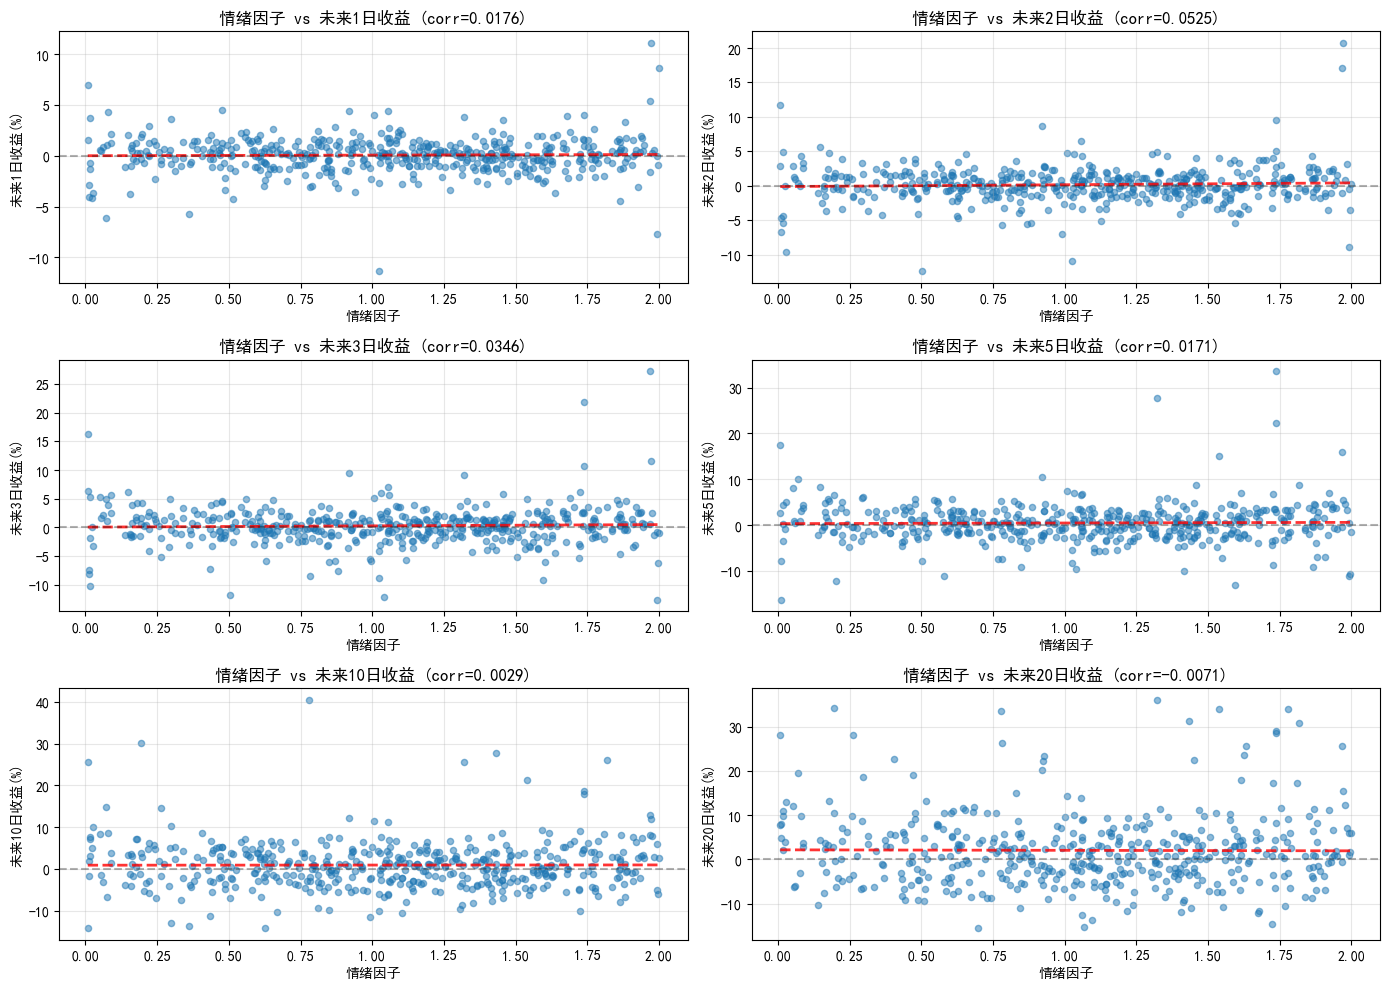

In [82]:
# 散点图：情绪因子 vs 未来5日收益（修复np.polyfit报错）
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
periods = [1, 2, 3 ,5, 10, 20]

for i, period in enumerate(periods):
    ax = axes[i//2, i%2]
    
    # 先清理数据：去掉NaN
    valid_data = analysis_data[[
        'sentiment_factor', 
        f'future_return_{period}d'
    ]].dropna()
    
    ax.scatter(valid_data['sentiment_factor'], 
               valid_data[f'future_return_{period}d'], 
               alpha=0.5, s=20)
    
    # 添加趋势线（添加try-except保护，避免报错）
    if len(valid_data) > 2:  # 确保有足够的数据点
        try:
            z = np.polyfit(valid_data['sentiment_factor'], 
                          valid_data[f'future_return_{period}d'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(valid_data['sentiment_factor'].min(), 
                                  valid_data['sentiment_factor'].max(), 100)
            ax.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2)
        except Exception as e:
            print(f"周期{period}天趋势线计算失败: {e}")
    
    corr = analysis_data['sentiment_factor'].corr(analysis_data[f'future_return_{period}d'])
    ax.set_title(f'情绪因子 vs 未来{period}日收益 (corr={corr:.4f})', fontsize=12)
    ax.set_xlabel('情绪因子')
    ax.set_ylabel(f'未来{period}日收益(%)')
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 步骤5：分组测试

情绪因子分组未来2日收益统计:
              平均收益(%)   收益标准差  样本数
factor_group                      
G1             0.3691  3.4473   49
G2             0.1759  2.6685   47
G3            -0.0285  1.8288   45
G4            -0.3065  2.4182   49
G5             0.3095  2.8676   47
G6            -0.1680  1.6279   48
G7             0.0971  1.7809   46
G8            -0.1864  1.8193   49
G9             0.5048  2.7240   47
G10            0.9381  4.4112   47


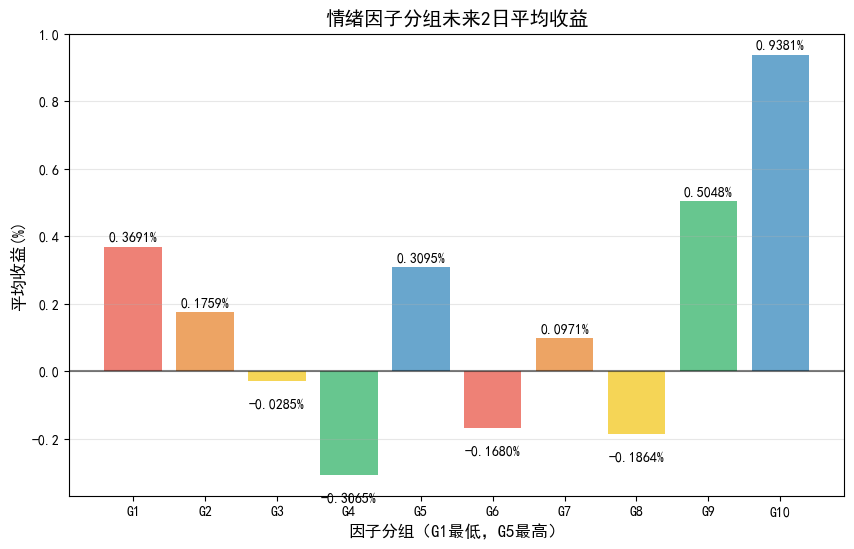

In [ ]:
# 将情绪因子分为5组
analysis_data_clean = analysis_data.dropna(subset=['sentiment_factor']).copy()
analysis_data_clean['factor_group'] = pd.qcut(analysis_data_clean['sentiment_factor'], 
                                               q=5, labels=['G1', 'G2', 'G3', 'G4', 'G5'])

# 看每组的未来收益
period = 2  # 用3天持仓期作为示例
group_returns = analysis_data_clean.groupby('factor_group')[f'future_return_{period}d'].agg([
    'mean', 'std', 'count'
])
group_returns.columns = ['平均收益(%)', '收益标准差', '样本数']

print(f"情绪因子分组未来{period}日收益统计:")
print(group_returns.round(4))

# 画柱状图
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
bars = plt.bar(group_returns.index, group_returns['平均收益(%)'], color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height>0 else -0.05),
             f'{height:.4f}%', ha='center', va='bottom' if height>0 else 'top')

plt.title(f'情绪因子分组未来{period}日平均收益', fontsize=14)
plt.xlabel('因子分组（G1最低，G5最高）', fontsize=12)
plt.ylabel('平均收益(%)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.show()

## 步骤5.5：每个分组作为独立策略回测

In [84]:
def backtest_group_strategy(data, group_col, target_group, hold_period=5):
    """
    单个分组策略回测
    
    参数:
    - data: 包含因子分组和收益率的数据
    - group_col: 分组列名
    - target_group: 目标分组（如'G1', 'G2'等）
    - hold_period: 持仓天数
    """
    data = data.copy().dropna(subset=[group_col])
    
    # 计算信号：当因子处于目标分组时
    data['signal'] = (data[group_col] == target_group).astype(int)
    
    # 仓位：新信号出现时，剩余持仓天数重置为 hold_period
    signal_arr = data['signal'].to_numpy()
    position = np.zeros(len(data), dtype=np.int8)
    remaining_days = 0

    for i, s in enumerate(signal_arr):
        if s == 1:
            remaining_days = hold_period  # 重置持有期
        if remaining_days > 0:
            position[i] = 1
            remaining_days -= 1

    data['position'] = position

    # 策略收益与净值
    data['strategy_return'] = data['position'] * data['daily_return'] / 100
    data['strategy_nav'] = (1 + data['strategy_return']).cumprod()

    return data

# 对每个分组进行回测
hold_period = 3
groups = ['G1', 'G2', 'G3', 'G4', 'G5']
group_results = {}

for group in groups:
    group_strategy = backtest_group_strategy(
        analysis_data_clean, 'factor_group', target_group=group, hold_period=hold_period
    )
    group_results[group] = group_strategy

print("所有分组策略回测完成")

所有分组策略回测完成


所有分组策略表现汇总
           累计收益     年化收益   夏普比率     最大回撤      胜率     持仓占比
分组                                                       
G1      -45.85%  -27.73%  -1.54  -49.92%  21.22%   45.59%
G2       -8.96%   -4.85%  -0.48  -26.79%  22.27%   43.49%
G3       10.80%    5.58%   0.23  -16.92%  26.47%   48.32%
G4       45.99%   22.18%   1.30   -7.96%  27.73%   48.32%
G5      187.23%   74.82%   2.71   -8.83%  25.00%   39.08%
买入持有基准   36.25%   17.79%   0.61  -22.78%  54.62%  100.00%


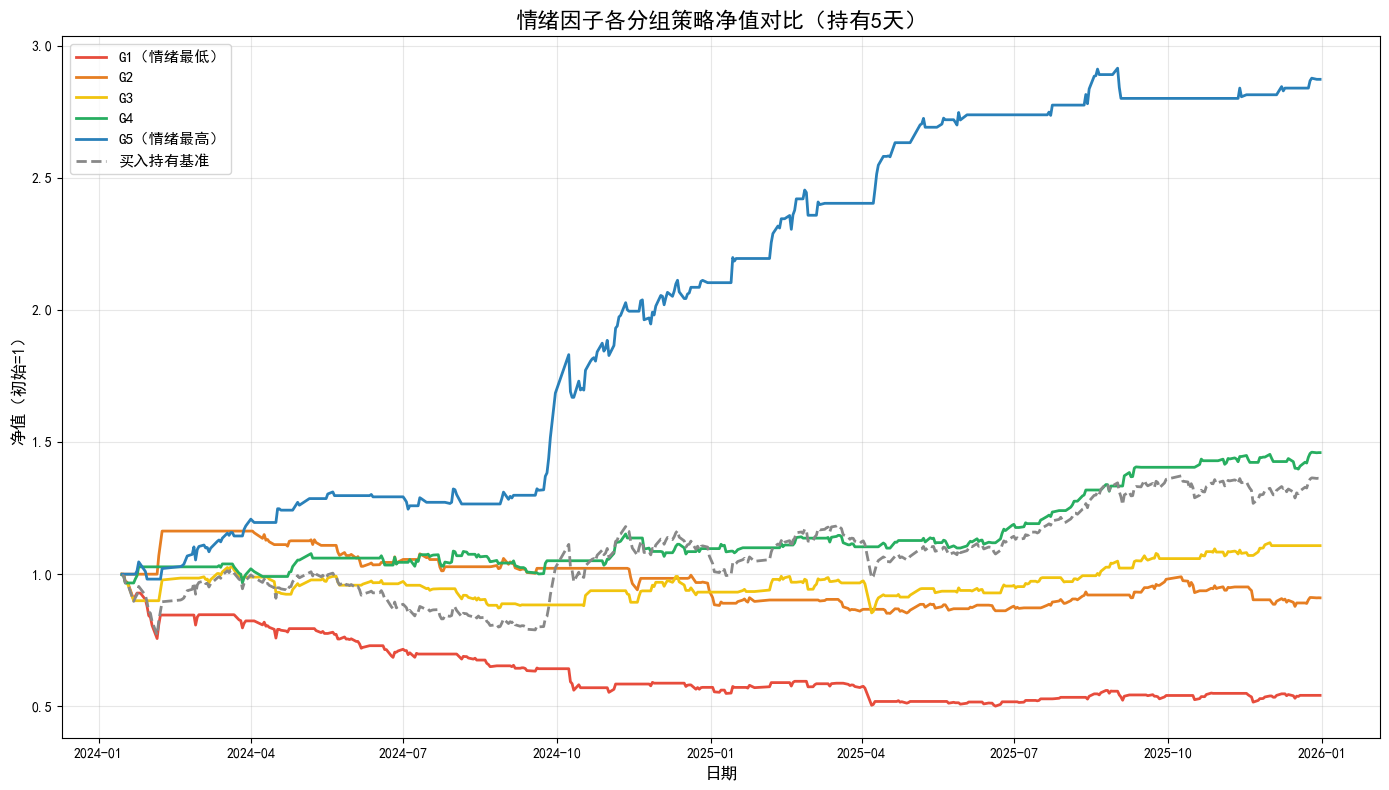

In [85]:
def calculate_group_performance_metrics(data, group_name):
    """计算分组策略表现指标"""
    returns = data['strategy_return'].dropna()
    nav = data['strategy_nav'].dropna()
    
    if len(returns) == 0:
        return None
    
    # 年化收益率
    total_return = nav.iloc[-1] - 1
    years = len(returns) / 252
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    # 夏普比率（假设无风险利率3%）
    daily_rf = 0.03 / 252
    excess_return = returns - daily_rf
    sharpe = np.sqrt(252) * excess_return.mean() / returns.std() if returns.std() > 0 else 0
    
    # 最大回撤
    peak = nav.expanding().max()
    drawdown = (nav - peak) / peak
    max_drawdown = drawdown.min()
    
    # 胜率
    win_rate = (returns > 0).mean()
    
    # 持仓天数占比
    position_days = (data['position'] == 1).sum()
    position_ratio = position_days / len(data)
    
    return {
        '分组': group_name,
        '累计收益': total_return * 100,
        '年化收益': annual_return * 100,
        '夏普比率': sharpe,
        '最大回撤': max_drawdown * 100,
        '胜率': win_rate * 100,
        '持仓占比': position_ratio * 100
    }

# 计算所有分组的表现
all_metrics = []
for group in groups:
    metrics = calculate_group_performance_metrics(group_results[group], group)
    all_metrics.append(metrics)

# 添加基准
benchmark_data = analysis_data_clean.copy()
benchmark_data['position'] = 1
benchmark_data['strategy_return'] = benchmark_data['daily_return'] / 100
benchmark_data['strategy_nav'] = (1 + benchmark_data['strategy_return']).cumprod()
benchmark_metrics = calculate_group_performance_metrics(benchmark_data, '买入持有基准')
all_metrics.append(benchmark_metrics)

# 转为DataFrame并格式化
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.set_index('分组')

# 显示格式化后的表格
print("="*90)
print("所有分组策略表现汇总")
print("="*90)
display_df = metrics_df.copy()
for col in ['累计收益', '年化收益', '最大回撤', '胜率', '持仓占比']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}%')
display_df['夏普比率'] = display_df['夏普比率'].apply(lambda x: f'{x:.2f}')
print(display_df)

# 画出所有分组策略的净值曲线对比
plt.figure(figsize=(14, 8))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9', '#888888']
labels = ['G1（情绪最低）', 'G2', 'G3', 'G4', 'G5（情绪最高）', '买入持有基准']

for i, group in enumerate(groups + ['基准']):
    if group == '基准':
        nav = benchmark_data['strategy_nav']
        linestyle = '--'
        linewidth = 2
    else:
        nav = group_results[group]['strategy_nav']
        linestyle = '-'
        linewidth = 2
    
    plt.plot(nav.index, nav, label=labels[i], color=colors[i], 
             linestyle=linestyle, linewidth=linewidth)

plt.title('情绪因子各分组策略净值对比（持有5天）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('净值（初始=1）', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 分组策略回测结果分析

根据每个分组作为独立策略的回测结果，我们可以观察到：

1. **单调性验证**：理想的情绪因子应该呈现 G1 < G2 < G3 < G4 < G5（情绪越高，未来收益越高）或 G1 > G2 > G3 > G4 > G5（情绪越高，未来收益越低）的单调关系。

2. **多空收益差**：G5 - G1 的收益差越大，说明因子的区分能力越强。

3. **策略实用性**：
   - 重点关注 G5（情绪最高）组是否能稳定跑赢基准
   - 关注 G1（情绪最低）组是否显著跑输基准（可用于做空或规避）
   - 夏普比率和最大回撤也是重要的风险调整后收益指标

## 步骤6：择时策略回测

In [86]:
def backtest_timing_strategy(data, factor_col, signal_type='high', hold_period=5, threshold=0.8):
    """
    择时策略回测
    
    参数:
    - data: 包含因子和收益率的数据
    - factor_col: 因子列名
    - signal_type: 'high'=因子高时做多, 'low'=因子低时做多
    - hold_period: 持仓天数
    - threshold: 分位数阈值（如0.8表示最高20%）
    """
    data = data.copy().dropna(subset=[factor_col])
    
    # 计算信号
    if signal_type == 'high':
        threshold_value = data[factor_col].quantile(threshold)
        data['signal'] = (data[factor_col] >= threshold_value).astype(int)
    else:  # low
        threshold_value = data[factor_col].quantile(1 - threshold)
        data['signal'] = (data[factor_col] <= threshold_value).astype(int)
    
    # 持仓：有信号时持有hold_period天
    data['position'] = 0
    in_position = False
    hold_days = 0
    
    for i in range(len(data)):
        if not in_position and data['signal'].iloc[i] == 1:
            in_position = True
            hold_days = 0
        
        if in_position:
            data['position'].iloc[i] = 1
            hold_days += 1
            if hold_days >= hold_period:
                in_position = False
    
    # 计算策略收益
    data['strategy_return'] = data['position'] * data['daily_return'] / 100
    data['benchmark_return'] = data['daily_return'] / 100
    
    # 计算净值
    data['strategy_nav'] = (1 + data['strategy_return']).cumprod()
    data['benchmark_nav'] = (1 + data['benchmark_return']).cumprod()
    
    return data

# 回测两种策略
hold_period = 5
threshold = 0.8  # 用最高/最低20%作为信号

strategy_high = backtest_timing_strategy(
    analysis_data, 'sentiment_factor', signal_type='high', 
    hold_period=hold_period, threshold=threshold
)

strategy_low = backtest_timing_strategy(
    analysis_data, 'sentiment_factor', signal_type='low', 
    hold_period=hold_period, threshold=threshold
)

print("策略回测完成")

策略回测完成


In [87]:
def calculate_performance_metrics(data, return_col, nav_col):
    """计算策略表现指标"""
    returns = data[return_col].dropna()
    nav = data[nav_col].dropna()
    
    if len(returns) == 0:
        return None
    
    # 年化收益率
    total_return = nav.iloc[-1] - 1
    years = len(returns) / 252
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    
    # 夏普比率（假设无风险利率3%）
    daily_rf = 0.03 / 252
    excess_return = returns - daily_rf
    sharpe = np.sqrt(252) * excess_return.mean() / returns.std() if returns.std() > 0 else 0
    
    # 最大回撤
    peak = nav.expanding().max()
    drawdown = (nav - peak) / peak
    max_drawdown = drawdown.min()
    
    # 胜率
    win_rate = (returns > 0).mean()
    
    # 持仓天数占比
    position_days = (data['position'] == 1).sum()
    position_ratio = position_days / len(data)
    
    return {
        '累计收益': f'{total_return*100:.2f}%',
        '年化收益': f'{annual_return*100:.2f}%',
        '夏普比率': f'{sharpe:.2f}',
        '最大回撤': f'{max_drawdown*100:.2f}%',
        '胜率': f'{win_rate*100:.2f}%',
        '持仓占比': f'{position_ratio*100:.2f}%'
    }

# 计算表现
print("="*60)
print("策略1：情绪因子高时做多")
print("="*60)
metrics_high = calculate_performance_metrics(strategy_high, 'strategy_return', 'strategy_nav')
for k, v in metrics_high.items():
    print(f"{k}: {v}")

print("\n" + "="*60)
print("策略2：情绪因子低时做多（逆向策略）")
print("="*60)
metrics_low = calculate_performance_metrics(strategy_low, 'strategy_return', 'strategy_nav')
for k, v in metrics_low.items():
    print(f"{k}: {v}")

print("\n" + "="*60)
print("基准：买入持有中证1000")
print("="*60)
# 基准指标
benchmark_data = strategy_high.copy()
benchmark_data['position'] = 1  # 满仓
benchmark_data['strategy_return'] = benchmark_data['benchmark_return']
benchmark_data['strategy_nav'] = benchmark_data['benchmark_nav']
metrics_benchmark = calculate_performance_metrics(benchmark_data, 'strategy_return', 'strategy_nav')
for k, v in metrics_benchmark.items():
    print(f"{k}: {v}")

策略1：情绪因子高时做多
累计收益: 148.34%
年化收益: 61.86%
夏普比率: 2.26
最大回撤: -11.07%
胜率: 27.94%
持仓占比: 45.17%

策略2：情绪因子低时做多（逆向策略）
累计收益: -40.06%
年化收益: -23.73%
夏普比率: -1.23
最大回撤: -43.37%
胜率: 26.05%
持仓占比: 54.62%

基准：买入持有中证1000
累计收益: 36.25%
年化收益: 17.79%
夏普比率: 0.61
最大回撤: -22.78%
胜率: 54.62%
持仓占比: 100.00%


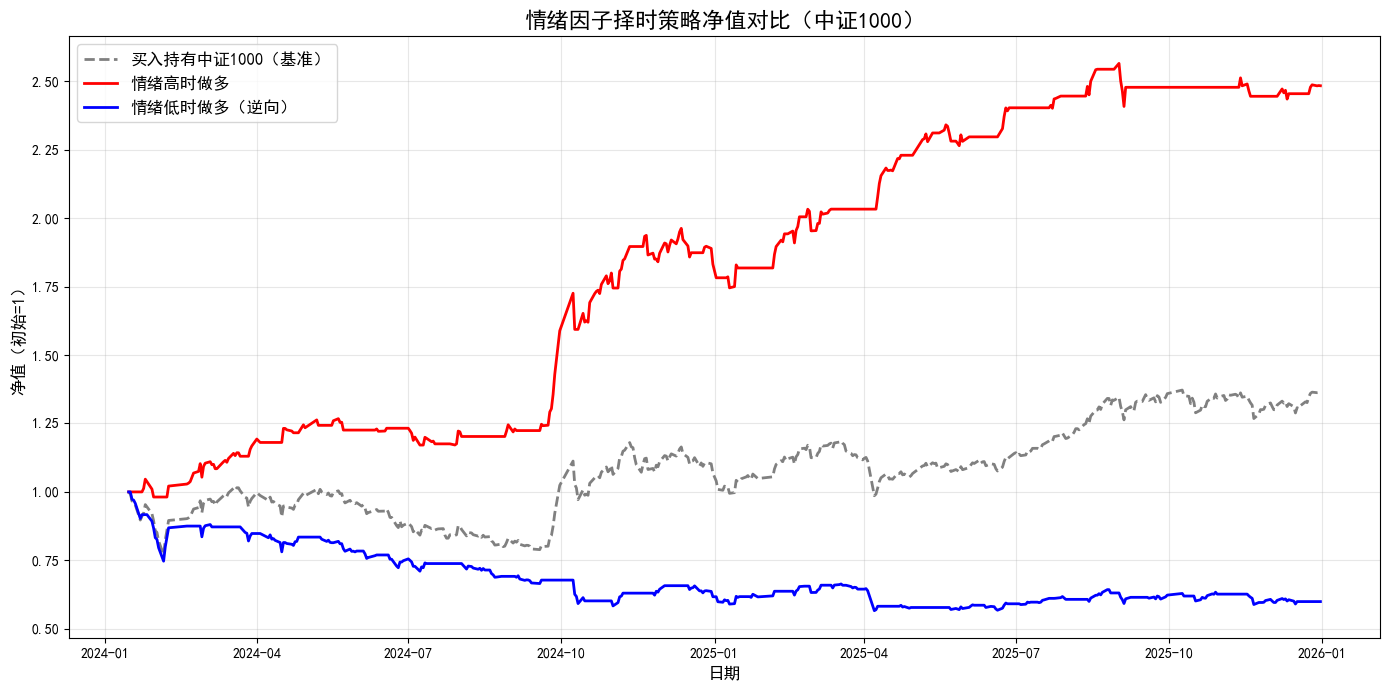

In [88]:
# 画出净值曲线
plt.figure(figsize=(14, 7))

plt.plot(strategy_high.index, strategy_high['benchmark_nav'], 
         label='买入持有中证1000（基准）', color='gray', linewidth=2, linestyle='--')
plt.plot(strategy_high.index, strategy_high['strategy_nav'], 
         label='情绪高时做多', color='red', linewidth=2)
plt.plot(strategy_low.index, strategy_low['strategy_nav'], 
         label='情绪低时做多（逆向）', color='blue', linewidth=2)

plt.title('情绪因子择时策略净值对比（中证1000）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('净值（初始=1）', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 步骤7：量化因子指标评价标准参考

### 1. 相关性系数（Correlation）评价标准

| 相关系数 | 评价 | 说明 |
|---------|------|------|
| \|r\| < 0.05 | 很弱 | 几乎没有预测能力 |
| 0.05 ≤ \|r\| < 0.1 | 较弱 | 有一定预测能力，但不稳定 |
| 0.1 ≤ \|r\| < 0.2 | 中等 | 较好的预测能力 |
| 0.2 ≤ \|r\| < 0.3 | 较强 | 很好的预测能力 |
| \|r\| ≥ 0.3 | 很强 | 非常优秀的预测能力（较少见） |

### 2. 择时策略表现指标评价标准

| 指标 | 较差 | 一般 | 良好 | 优秀 |
|------|------|------|------|------|
| 年化收益 | < 5% | 5-10% | 10-20% | > 20% |
| 夏普比率 | < 0.5 | 0.5-1.0 | 1.0-2.0 | > 2.0 |
| 最大回撤 | > -30% | -20%~-30% | -10%~-20% | < -10% |
| 胜率 | < 50% | 50-55% | 55-60% | > 60% |

### 3. 分组收益单调性评价

- **理想情况**：G1 < G2 < G3 < G4 < G5（单调递增）或 G1 > G2 > G3 > G4 > G5（单调递减）
- **可接受**：G1和G5有明显差异，中间有一定趋势
- **较差**：分组收益混乱，无明显趋势

### 4. 多头空头收益差（G5 - G1）评价标准

| 多空收益差（5日） | 评价 |
|------------------|------|
| < 1% | 较差 |
| 1-2% | 一般 |
| 2-4% | 良好 |
| > 4% | 优秀 |

## 总结

这个notebook实现了情绪因子的完整测试流程：

1. **因子计算**：
   - 涨跌停家数差的252日百分位排名
   - 昨日涨停今日溢价的252日百分位排名
   - 两者相加得到情绪因子

2. **使用中证1000指数（SHSE.000852）进行测试**：
   - 通过`api.gm_get_index_day_data()`获取真实指数数据

3. **分析内容**：
   - 情绪因子时序图
   - 因子与未来收益的相关性
   - 分组测试（G1-G5）
   - **每个分组作为独立策略回测**（新增）
     - G1-G5各组策略的净值曲线对比
     - 各组策略表现指标汇总（年化收益、夏普比率、最大回撤、胜率）
   - 择时策略回测（情绪高/低时做多）
   - 与买入持有基准对比
   - 量化因子指标评价标准参考